In [1]:
import pandas as pd
import numpy as np
from utils import preprocess, models
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import matplotlib.dates as mdates
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("data/1082-Device-Data-Fix.csv")
df = preprocess.get_clean_df(df)
df = preprocess.create_standarized_gradients(df)
df = preprocess.create_steps_from_irrigation(df)

In [3]:
THRESH_DOWN = -0.1
THRESH_UP = 0.1

plain_model = models.get_plain_predictor()

plain_dates = preprocess.get_plains_dates(df, THRESH_DOWN, THRESH_UP)
df["plain"] = False
df.loc[df["date"].isin(plain_dates), "plain"] = True
df_decay = preprocess.get_dataset_from_df(df, THRESH_UP)
df_decay.head()

X = preprocess.get_inputs_plain_predictor(df_decay)
df_decay["plain"] = plain_model.predict(X)
df_decay["plain"] = df_decay["plain"].astype(bool)

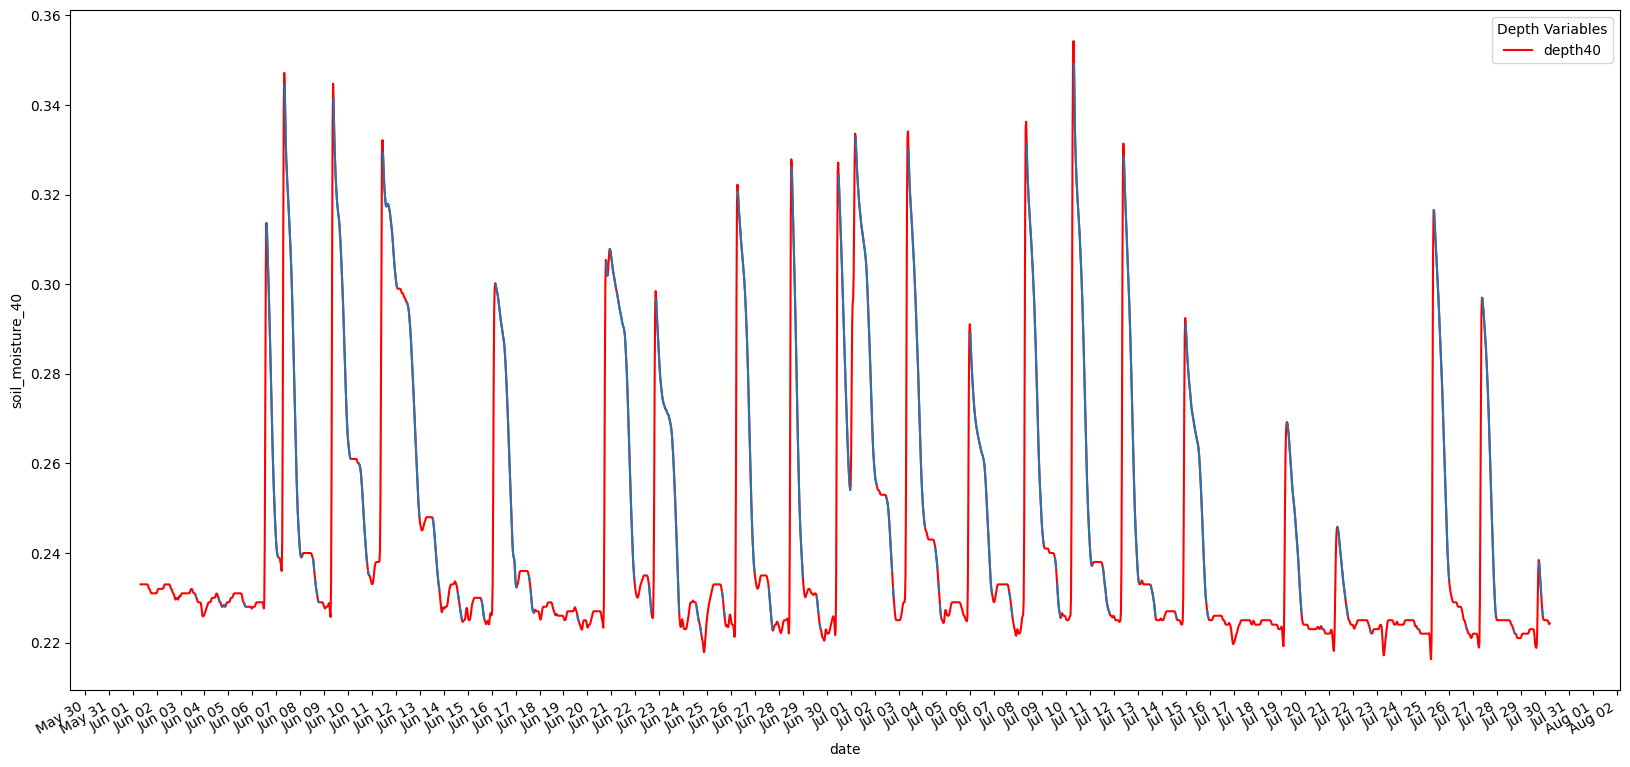

In [4]:
start_date = pd.to_datetime("2024-06-01 08:00:00")
end_date   = pd.to_datetime("2024-07-30 05:00:00")
df_constricted = df[(df["date"] >= start_date) & (df["date"] <= end_date)]
#We use the gradients to detect slopes and plains, but we first normalize to be able to get good scales for thresholding

restricted_mask = ~df_decay["plain"] & ~df_decay["up"]
restricted_dates = df_decay.loc[restricted_mask, "date"]

restricted_df = df_constricted.copy()
restricted_df["soil_moisture_40"] = np.nan
restricted_df["soil_moisture_40"] = df_constricted.loc[df_constricted["date"].isin(restricted_dates), "soil_moisture_40"]

plt.figure(figsize=(20, 10))

sns.lineplot(df_constricted, x="date", y="soil_moisture_40", label="depth40", color="red")
plt.plot(restricted_df["date"], np.ma.masked_invalid(restricted_df["soil_moisture_40"].astype(float)))
# sns.lineplot(plain_df, x="date", y="soil_moisture_40", label="plain", color="blue")
plt.legend(title="Depth Variables")
# plt.ylim(0, 0.40)
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.gcf().autofmt_xdate()  # rotate labels for clarity
plt.show()
plt.show()

In [5]:
df_decay = preprocess.separate_slopes_by_groups(df_decay)
df_decay.head()

,date,soil_moisture_40,steps_from_peak,plain,up,season_autumn,season_spring,season_summer,season_winter,hour_s,hour_c,group
0,2023-01-01 00:30:00,0.277,0,True,False,False,False,False,True,0.000000e+00,1.0,NaN
1,2023-01-01 01:00:00,0.277,1,True,False,False,False,False,True,-2.449294e-16,1.0,NaN
2,2023-01-01 01:30:00,0.277,2,True,False,False,False,False,True,-2.449294e-16,1.0,NaN
3,2023-01-01 02:00:00,0.277,3,True,False,False,False,False,True,-4.898587e-16,1.0,NaN
4,2023-01-01 02:30:00,0.277,4,True,False,False,False,False,True,-4.898587e-16,1.0,NaN
